In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer


In [2]:
movies= pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")
tags= pd.read_csv("tags.csv")
links= pd.read_csv("links.csv")

### Movies_info

In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
movies.tail()

,movieId,title,genres
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation
9741,193609,Andrew Dice Clay: Dice Rules (1991),Comedy


In [6]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


In [7]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [8]:
movies.duplicated().sum()

np.int64(0)

In [9]:
movies.shape

(9742, 3)

In [10]:
movies["movieId"].nunique()

9742

In [11]:
movies["genres"].nunique()

951

In [12]:
movies["genres"].str.split("|").explode().nunique()

20

In [13]:
movies["genres"].str.split("|").explode().unique()

<StringArray>
[         'Adventure',          'Animation',           'Children',
             'Comedy',            'Fantasy',            'Romance',
              'Drama',             'Action',              'Crime',
           'Thriller',             'Horror',            'Mystery',
             'Sci-Fi',                'War',            'Musical',
        'Documentary',               'IMAX',            'Western',
          'Film-Noir', '(no genres listed)']
Length: 20, dtype: str

In [14]:
movies["genres"].str.split("|").explode().value_counts()


genres
Drama                 4361
Comedy                3756
Thriller              1894
Action                1828
Romance               1596
Adventure             1263
Crime                 1199
Sci-Fi                 980
Horror                 978
Fantasy                779
Children               664
Animation              611
Mystery                573
Documentary            440
War                    382
Musical                334
Western                167
IMAX                   158
Film-Noir               87
(no genres listed)      34
Name: count, dtype: int64

In [15]:
movies["genres"] = movies["genres"].str.replace("|", " ")

movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy Romance
3,4,Waiting to Exhale (1995),Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy


In [16]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    tokenizer=lambda x: x.split(),
    token_pattern=None
)

movies["genres_clean"] = movies["genres"].replace(
    "(no genres listed)", ""
)

genre_matrix = vectorizer.fit_transform(movies["genres_clean"])

In [17]:
genre_matrix.shape

(9742, 19)

In [18]:
vectorizer.get_feature_names_out()

array(['action', 'adventure', 'animation', 'children', 'comedy', 'crime',
       'documentary', 'drama', 'fantasy', 'film-noir', 'horror', 'imax',
       'musical', 'mystery', 'romance', 'sci-fi', 'thriller', 'war',
       'western'], dtype=object)

### ratings_info

In [19]:
ratings.sample(5)

,userId,movieId,rating,timestamp
80965,511,50601,3.0,1522155907
82161,520,63113,2.5,1326611020
42467,288,2043,3.0,978467899
871,6,1073,3.0,845555571
91764,596,527,4.0,1535827023


In [20]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [21]:
ratings.duplicated().sum()

np.int64(0)

In [22]:
#ولو نفس المستخدم قيم نفس الفيلم مره تانية بتوقيت مختلف، الصفين مش هيكونوا duplicates بالكامل.

In [23]:
ratings.shape

(100836, 4)

In [24]:
ratings["userId"].nunique()

610

In [25]:
ratings["rating"].unique()

array([4. , 5. , 3. , 2. , 1. , 4.5, 3.5, 2.5, 0.5, 1.5])

In [26]:
ratings["rating"].value_counts()

rating
4.0    26818
3.0    20047
5.0    13211
3.5    13136
4.5     8551
2.0     7551
2.5     5550
1.0     2811
1.5     1791
0.5     1370
Name: count, dtype: int64

In [27]:
ratings["rating"].mean()

np.float64(3.501556983616962)

In [28]:
ratings["rating"].min()
ratings["rating"].max()

np.float64(5.0)

In [29]:
ratings["movieId"].value_counts().head()

movieId
356     329
318     317
296     307
593     279
2571    278
Name: count, dtype: int64

In [30]:
ratings["movieId"].value_counts().min()

np.int64(1)

In [31]:
ratings["movieId"].value_counts().max()

np.int64(329)

In [32]:
ratings["movieId"].value_counts().mean()

np.float64(10.369806663924312)

### Tags_info

In [33]:
tags.sample(5)

,userId,movieId,tag,timestamp
160,62,38061,Robert Downey Jr.,1532723408
3369,599,293,loneliness,1498456186
2939,567,1921,tense,1525287285
604,318,82459,Matt Damon,1300485480
1323,474,1197,six-fingered man,1137202999


In [34]:
tags.info()

<class 'pandas.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   userId     3683 non-null   int64
 1   movieId    3683 non-null   int64
 2   tag        3683 non-null   str  
 3   timestamp  3683 non-null   int64
dtypes: int64(3), str(1)
memory usage: 115.2 KB


In [35]:
tags.duplicated().sum()

np.int64(0)

In [36]:
tags.shape

(3683, 4)

### links_info

In [37]:
links.sample(5)

,movieId,imdbId,tmdbId
5707,27816,373283,10105.0
4605,6858,56291,11502.0
5656,27539,298504,10918.0
1907,2531,69768,1705.0
3714,5128,238546,11979.0


In [38]:
links.info()

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  9742 non-null   int64  
 1   imdbId   9742 non-null   int64  
 2   tmdbId   9734 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 228.5 KB


In [39]:
links.isnull().sum()

movieId    0
imdbId     0
tmdbId     8
dtype: int64

In [40]:
links.duplicated().sum()

np.int64(0)

In [41]:
links.shape

(9742, 3)

### EDA

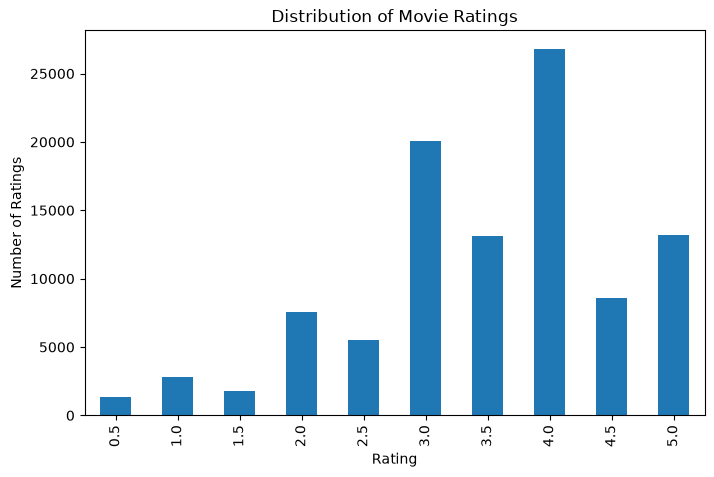

In [42]:
ratings["rating"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5),
    title="Distribution of Movie Ratings"
)
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.show()

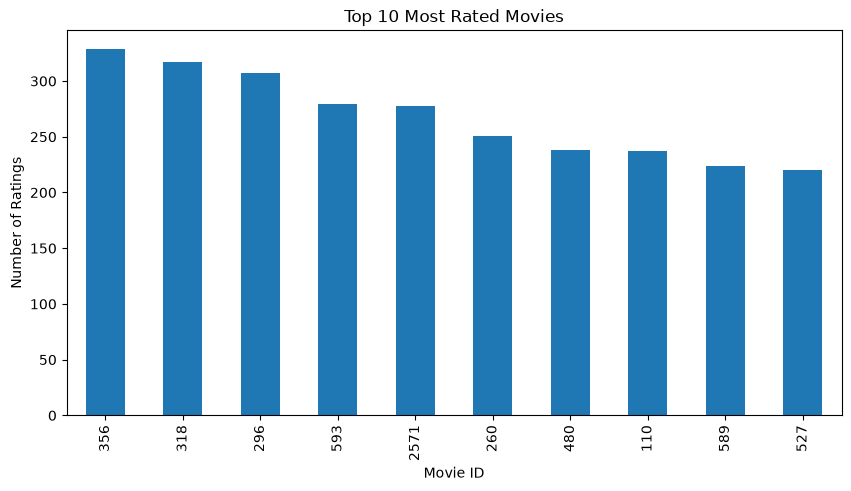

In [43]:
ratings["movieId"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Most Rated Movies"
)

plt.xlabel("Movie ID")
plt.ylabel("Number of Ratings")
plt.show()

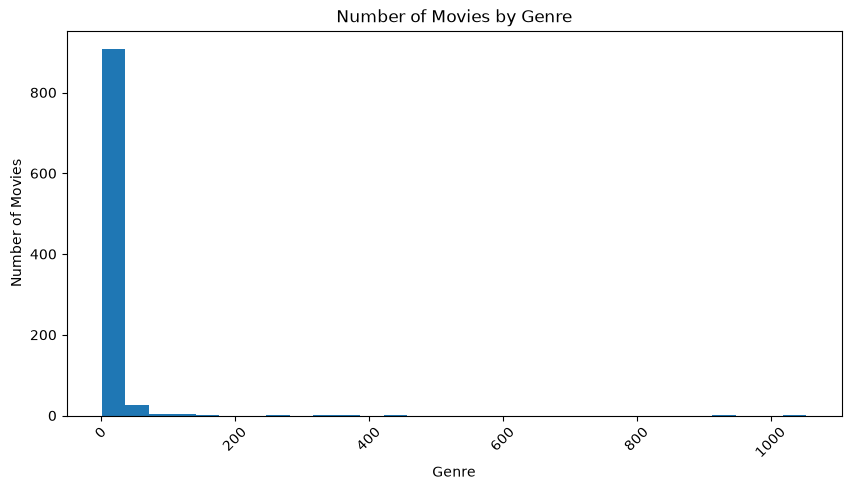

In [44]:
genre_counts = movies["genres"].str.split("|").explode().value_counts()

genre_counts.plot(
    kind="hist",
    bins=30,
    figsize=(10, 5),
    title="Number of Movies by Genre"
)

plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()

In [45]:
genre_ratings = (
    movies[["movieId", "genres"]]
    .assign(genre=movies["genres"].str.split("|"))
    .explode("genre")
    .merge(ratings[["movieId", "rating"]], on="movieId")
    .groupby("genre")["rating"]
    .mean()
    .sort_values(ascending=False)
)

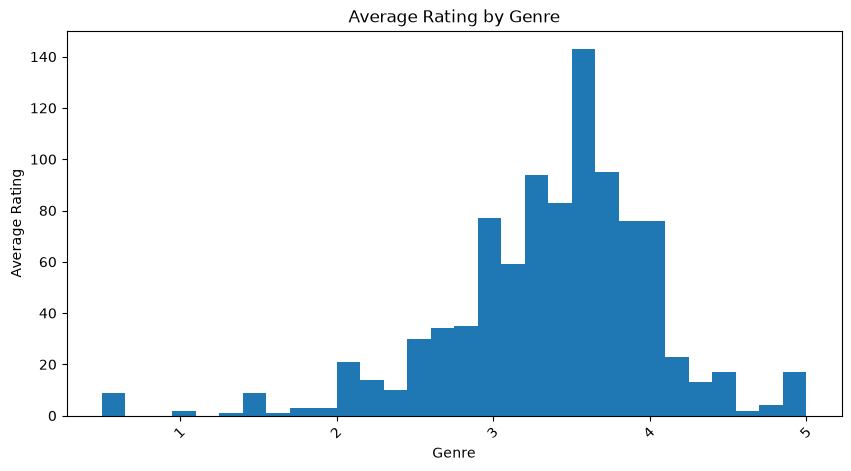

In [46]:
genre_ratings.plot(
    kind="hist",
    bins=30,
    figsize=(10, 5),
    title="Average Rating by Genre"
)

plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

In [47]:
user_count=ratings["userId"].value_counts()

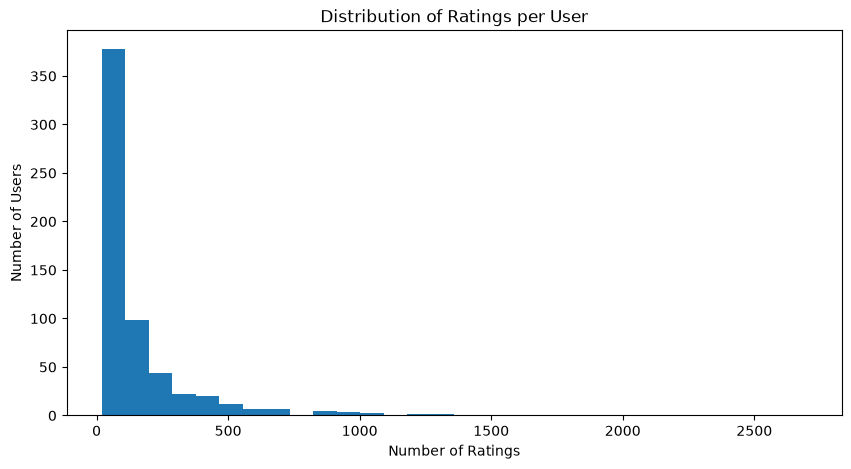

In [48]:
user_count.plot(
    kind="hist",
    bins=30,
    figsize=(10, 5),
    title="Distribution of Ratings per User"
)
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()

In [49]:
movie_stats = ratings.groupby("movieId")["rating"].agg(
    ["count", "mean"])

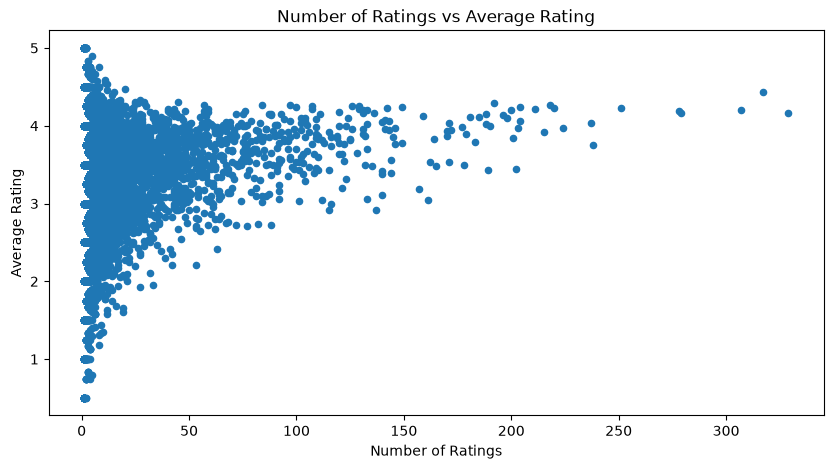

In [50]:
movie_stats.plot(
    kind="scatter",
    x="count",
    y="mean",
    figsize=(10, 5),
    title="Number of Ratings vs Average Rating"
)

plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.show()

### Cosine Similarity

In [51]:
from sklearn.metrics.pairwise import cosine_similarity

In [52]:
similarity_matrix = cosine_similarity(genre_matrix)

In [53]:
similarity_matrix.shape

(9742, 9742)

In [54]:
movies.iloc[0]["title"]

'Toy Story (1995)'

In [55]:
similarity_matrix[0]

array([1.        , 0.77459667, 0.31622777, ..., 0.        , 0.31622777,
       0.4472136 ], shape=(9742,))

In [56]:
similarity_matrix[0][1]

np.float64(0.7745966692414834)

In [57]:
movie_index = movies[movies["title"] == "Toy Story (1995)"].index[0]

In [58]:
similarity_scores = list(
    enumerate(similarity_matrix[movie_index])
)

In [59]:
similarity_scores = sorted(
    similarity_scores,
    key=lambda x: x[1],
    reverse=True
)

In [60]:
for movie_index, score in similarity_scores[1:11]:
    print(movies.iloc[movie_index]["title"], "→", round(score, 3))

Antz (1998) → 1.0
Toy Story 2 (1999) → 1.0
Adventures of Rocky and Bullwinkle, The (2000) → 1.0
Emperor's New Groove, The (2000) → 1.0
Monsters, Inc. (2001) → 1.0
Wild, The (2006) → 1.0
Shrek the Third (2007) → 1.0
Tale of Despereaux, The (2008) → 1.0
Asterix and the Vikings (Astérix et les Vikings) (2006) → 1.0
Turbo (2013) → 1.0


### recommend_movies()

In [61]:
def recommend_movies(movie_title, n=10):
    
    movie_index = movies[movies["title"] == movie_title].index[0]
    
    
    similarity_scores = list(
        enumerate(similarity_matrix[movie_index])
    )
    

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )
    
    recommendations = []
    
    for index, score in similarity_scores[1:n+1]:
        recommendations.append({
            "title": movies.iloc[index]["title"],
            "similarity": round(score, 3)
        })
    
    return recommendations

In [62]:
recommend_movies("Jumanji (1995)")

[{'title': 'Indian in the Cupboard, The (1995)',
  'similarity': np.float64(1.0)},
 {'title': 'NeverEnding Story III, The (1994)', 'similarity': np.float64(1.0)},
 {'title': 'Escape to Witch Mountain (1975)', 'similarity': np.float64(1.0)},
 {'title': "Darby O'Gill and the Little People (1959)",
  'similarity': np.float64(1.0)},
 {'title': 'Return to Oz (1985)', 'similarity': np.float64(1.0)},
 {'title': 'NeverEnding Story, The (1984)', 'similarity': np.float64(1.0)},
 {'title': 'NeverEnding Story II: The Next Chapter, The (1990)',
  'similarity': np.float64(1.0)},
 {'title': 'Santa Claus: The Movie (1985)', 'similarity': np.float64(1.0)},
 {'title': "Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone) (2001)",
  'similarity': np.float64(1.0)},
 {'title': 'Chronicles of Narnia: The Lion, the Witch and the Wardrobe, The (2005)',
  'similarity': np.float64(1.0)}]

___________

### tages + Collaborative Filtering

In [63]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [64]:
movie_tags = tags.groupby("movieId")["tag"].apply(
    lambda x: " ".join(x)
).reset_index()

movie_tags.head()

,movieId,tag
0,1,pixar pixar fun
1,2,fantasy magic board game Robin Williams game
2,3,moldy old
3,5,pregnancy remake
4,7,remake


In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [66]:
tfidf = TfidfVectorizer()

tag_matrix = tfidf.fit_transform(movie_tags["tag"])

In [67]:
tag_matrix.shape

(1572, 1744)

### movie_tags بجدول moviesربط 

In [68]:
movies_with_tags = movies.merge(
    movie_tags,
    on="movieId",
    how="left"
)
movies_with_tags[["movieId", "title", "genres", "tag"]].head()

,movieId,title,genres,tag
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,pixar pixar fun
1,2,Jumanji (1995),Adventure Children Fantasy,fantasy magic board game Robin Williams game
2,3,Grumpier Old Men (1995),Comedy Romance,moldy old
3,4,Waiting to Exhale (1995),Comedy Drama Romance,NaN
4,5,Father of the Bride Part II (1995),Comedy,pregnancy remake


In [69]:
movies_with_tags["tag"] = movies_with_tags["tag"].fillna("")
movies_with_tags.head()

,movieId,title,genres,genres_clean,tag
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,Adventure Animation Children Comedy Fantasy,pixar pixar fun
1,2,Jumanji (1995),Adventure Children Fantasy,Adventure Children Fantasy,fantasy magic board game Robin Williams game
2,3,Grumpier Old Men (1995),Comedy Romance,Comedy Romance,moldy old
3,4,Waiting to Exhale (1995),Comedy Drama Romance,Comedy Drama Romance,
4,5,Father of the Bride Part II (1995),Comedy,Comedy,pregnancy remake


In [70]:
movies_with_tags["combined_features"] = (
    movies_with_tags["genres_clean"] + " " +
    movies_with_tags["tag"]
)

In [71]:
movies_with_tags.head()

,movieId,title,genres,genres_clean,tag,combined_features
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,Adventure Animation Children Comedy Fantasy,pixar pixar fun,Adventure Animation Children Comedy Fantasy pi...
1,2,Jumanji (1995),Adventure Children Fantasy,Adventure Children Fantasy,fantasy magic board game Robin Williams game,Adventure Children Fantasy fantasy magic board...
2,3,Grumpier Old Men (1995),Comedy Romance,Comedy Romance,moldy old,Comedy Romance moldy old
3,4,Waiting to Exhale (1995),Comedy Drama Romance,Comedy Drama Romance,,Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy,Comedy,pregnancy remake,Comedy pregnancy remake


### Recommendation function

In [72]:
combined_tfidf = TfidfVectorizer()
combined_matrix = combined_tfidf.fit_transform(
    movies_with_tags["combined_features"]
)

In [73]:
combined_matrix.shape

(9742, 1746)

In [74]:
from sklearn.metrics.pairwise import cosine_similarity

combined_similarity = cosine_similarity(combined_matrix)

In [75]:
combined_similarity.shape

(9742, 9742)

In [76]:
movie_index = movies_with_tags[
    movies_with_tags["title"] == "Toy Story (1995)"
].index[0]

similarity_scores = list(
    enumerate(combined_similarity[movie_index])
)

similarity_scores = sorted(
    similarity_scores,
    key=lambda x: x[1],
    reverse=True
)

for index, score in similarity_scores[1:11]:
    print(
        movies_with_tags.iloc[index]["title"],
        "→",
        round(score, 3)
    )

Bug's Life, A (1998) → 0.862
Toy Story 2 (1999) → 0.644
Guardians of the Galaxy 2 (2017) → 0.368
Antz (1998) → 0.358
Adventures of Rocky and Bullwinkle, The (2000) → 0.358
Emperor's New Groove, The (2000) → 0.358
Monsters, Inc. (2001) → 0.358
Wild, The (2006) → 0.358
Shrek the Third (2007) → 0.358
Tale of Despereaux, The (2008) → 0.358


### Ratings + Collaborative Filtering

In [77]:
print("Number of users:", ratings["userId"].nunique())
print("Number of movies:", ratings["movieId"].nunique())
print("Number of ratings:", len(ratings))

Number of users: 610
Number of movies: 9724
Number of ratings: 100836


In [78]:
user_movie_matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

user_movie_matrix.shape

(610, 9724)

In [79]:
user_movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
user_movie_matrix_filled = user_movie_matrix.fillna(0)

user_movie_matrix_filled.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [81]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(user_movie_matrix_filled)

print(user_similarity.shape)

(610, 610)


In [82]:
user_similarity[:5, :5]

array([[1.        , 0.02728287, 0.05972026, 0.19439477, 0.12907989],
       [0.02728287, 1.        , 0.        , 0.00372587, 0.01661444],
       [0.05972026, 0.        , 1.        , 0.00225139, 0.00501972],
       [0.19439477, 0.00372587, 0.00225139, 1.        , 0.1286589 ],
       [0.12907989, 0.01661444, 0.00501972, 0.1286589 , 1.        ]])

In [83]:
user_id = 1

user_index = ratings[
    ratings["userId"] == user_id
]["userId"].iloc[0] - 1

similar_users = list(
    enumerate(user_similarity[user_index])
)

similar_users = sorted(
    similar_users,
    key=lambda x: x[1],
    reverse=True
)

for index, score in similar_users[1:6]:
    print(
        "User:", index + 1,
        "→ Similarity:", round(score, 3)
    )

User: 266 → Similarity: 0.357
User: 313 → Similarity: 0.352
User: 368 → Similarity: 0.345
User: 57 → Similarity: 0.345
User: 91 → Similarity: 0.335


In [84]:
similar_user_id = 266

similar_user_ratings = ratings[
    (ratings["userId"] == similar_user_id) &
    (ratings["rating"] >= 4)
]

similar_user_ratings.head(10)

,userId,movieId,rating,timestamp
38666,266,6,4.0,944980835
38667,266,16,5.0,944981193
38669,266,21,4.0,945669287
38671,266,32,4.0,945751855
38674,266,50,4.0,944980462
38676,266,69,5.0,945669505
38678,266,110,5.0,945670079
38683,266,223,4.0,944940274
38684,266,235,4.0,945669162
38685,266,260,4.0,945670679


In [85]:
print("Number of highly rated movies:",
      len(similar_user_ratings))

Number of highly rated movies: 103


In [86]:
top_similar_users = [
    266, 313, 368, 57, 91
]

similar_users_ratings = ratings[
    (ratings["userId"].isin(top_similar_users)) &
    (ratings["rating"] >= 4)
]

print(similar_users_ratings.shape)

(839, 4)


In [87]:
similar_users_ratings.head(10)

,userId,movieId,rating,timestamp
8035,57,1,5.0,965796031
8040,57,32,4.0,965798685
8042,57,50,5.0,965796686
8045,57,69,4.0,965797105
8051,57,110,4.0,965799491
8052,57,112,4.0,969754432
8053,57,141,4.0,965797105
8059,57,162,4.0,972172280
8060,57,171,4.0,965796904
8064,57,224,4.0,965797175


In [88]:
user_similarity_scores = {
    266: 0.357,
    313: 0.352,
    368: 0.345,
    57: 0.345,
    91: 0.335
}

similar_users_ratings["similarity"] = (
    similar_users_ratings["userId"].map(user_similarity_scores)
)

similar_users_ratings.head(10)

,userId,movieId,rating,timestamp,similarity
8035,57,1,5.0,965796031,0.345
8040,57,32,4.0,965798685,0.345
8042,57,50,5.0,965796686,0.345
8045,57,69,4.0,965797105,0.345
8051,57,110,4.0,965799491,0.345
8052,57,112,4.0,969754432,0.345
8053,57,141,4.0,965797105,0.345
8059,57,162,4.0,972172280,0.345
8060,57,171,4.0,965796904,0.345
8064,57,224,4.0,965797175,0.345


In [89]:
movie_scores = (
    similar_users_ratings
    .groupby("movieId")
    .apply(
        lambda x: (
            (x["rating"] * x["similarity"]).sum()
            / x["similarity"].sum()
        )
    )
    .reset_index(name="score")
)

movie_scores.head(10)


,movieId,score
0,1,4.507353
1,6,4.323047
2,10,4.000000
3,16,4.505786
4,21,4.000000
5,29,4.000000
6,32,4.000000
7,39,4.000000
8,41,4.000000
9,47,4.503391


In [90]:
movie_scores = movie_scores.sort_values(
    "score",
    ascending=False
)

movie_scores.head(10)

,movieId,score
552,8874,5.0
551,8636,5.0
530,6820,5.0
523,6539,5.0
525,6659,5.0
512,5540,5.0
20,163,5.0
500,5010,5.0
497,4941,5.0
506,5254,5.0


In [91]:
target_user = 1

rated_movies = set(
    ratings[ratings["userId"] == target_user]["movieId"]
)

print("Movies already rated by User 1:", len(rated_movies))

Movies already rated by User 1: 232


In [92]:
similar_users_ratings_all = ratings[
    ratings["userId"].isin(top_similar_users)
].copy()

similar_users_ratings_all["similarity"] = (
    similar_users_ratings_all["userId"].map(user_similarity_scores)
)

similar_users_ratings_all = similar_users_ratings_all[
    ~similar_users_ratings_all["movieId"].isin(rated_movies)
]

print(similar_users_ratings_all.shape)

(1530, 5)


In [93]:
movie_scores = (
    similar_users_ratings_all
    .groupby("movieId")
    .apply(
        lambda x: (
            (x["rating"] * x["similarity"]).sum()
            / x["similarity"].sum()
        )
    )
    .reset_index(name="collaborative_score")
)

movie_scores = movie_scores.sort_values(
    "collaborative_score",
    ascending=False
)

movie_scores.head(10)

,movieId,collaborative_score
326,1449,5.0
347,1591,5.0
362,1663,5.0
956,6820,5.0
948,6659,5.0
944,6539,5.0
898,5254,5.0
278,1284,5.0
277,1283,5.0
957,6857,5.0


In [94]:
movie_scores = (
    similar_users_ratings_all
    .groupby("movieId")
    .apply(
        lambda x: (
            (x["rating"] * x["similarity"]).sum()
            / x["similarity"].sum()
        )
    )
    .reset_index(name="collaborative_score")
)

movie_counts = (
    similar_users_ratings_all
    .groupby("movieId")
    .size()
    .reset_index(name="num_ratings")
)

movie_scores = movie_scores.merge(
    movie_counts,
    on="movieId"
)

movie_scores = movie_scores.sort_values(
    ["collaborative_score", "num_ratings"],
    ascending=[False, False]
)

movie_scores.head(15)

,movieId,collaborative_score,num_ratings
142,541,5.0,4
191,858,5.0,4
171,750,5.0,3
262,1252,5.0,2
653,3108,5.0,2
130,514,5.0,1
165,720,5.0,1
198,899,5.0,1
204,913,5.0,1
205,915,5.0,1


In [95]:
movie_scores_filtered = movie_scores[
    movie_scores["num_ratings"] >= 2
].copy()

movie_scores_filtered = movie_scores_filtered.sort_values(
    ["collaborative_score", "num_ratings"],
    ascending=[False, False]
)

movie_scores_filtered.head(15)

,movieId,collaborative_score,num_ratings
142,541,5.000000,4
191,858,5.000000,4
171,750,5.000000,3
262,1252,5.000000,2
653,3108,5.000000,2
241,1200,4.801038,5
764,3727,4.756186,2
891,4993,4.756186,2
435,2019,4.753676,2
240,1199,4.679119,3


In [96]:
target_user = 1

user_index = user_movie_matrix.index.get_loc(target_user)

similarity_scores = list(
    enumerate(user_similarity[user_index])
)

similarity_scores = sorted(
    similarity_scores,
    key=lambda x: x[1],
    reverse=True
)

top_20_similar_users = []

for index, score in similarity_scores:
    user_id = user_movie_matrix.index[index]

    if user_id != target_user:
        top_20_similar_users.append((user_id, score))

    if len(top_20_similar_users) == 20:
        break

top_20_similar_users

[(np.int64(266), np.float64(0.3574077096032742)),
 (np.int64(313), np.float64(0.35156151849095685)),
 (np.int64(368), np.float64(0.3451270515835304)),
 (np.int64(57), np.float64(0.3450342788075837)),
 (np.int64(91), np.float64(0.3347269204181708)),
 (np.int64(469), np.float64(0.3306643150652009)),
 (np.int64(39), np.float64(0.32978223365752674)),
 (np.int64(288), np.float64(0.32969952928292884)),
 (np.int64(452), np.float64(0.3280483444245288)),
 (np.int64(45), np.float64(0.32792168977722036)),
 (np.int64(19), np.float64(0.32537616030589694)),
 (np.int64(590), np.float64(0.32476626931234126)),
 (np.int64(135), np.float64(0.32397115454397096)),
 (np.int64(330), np.float64(0.3221009263883462)),
 (np.int64(480), np.float64(0.3207750664277381)),
 (np.int64(217), np.float64(0.3207129677163324)),
 (np.int64(577), np.float64(0.31731916472307153)),
 (np.int64(561), np.float64(0.3152540150361879)),
 (np.int64(64), np.float64(0.3152116613468185)),
 (np.int64(597), np.float64(0.31284260192629904)

In [97]:
# Extract user IDs only
top_20_user_ids = [
    user_id for user_id, similarity in top_20_similar_users
]

# Get ratings from the 20 similar users
similar_users_ratings_20 = ratings[
    ratings["userId"].isin(top_20_user_ids)
].copy()

# Add similarity score for each user
similarity_dict = dict(top_20_similar_users)

similar_users_ratings_20["similarity"] = (
    similar_users_ratings_20["userId"].map(similarity_dict)
)

print("Shape:", similar_users_ratings_20.shape)
similar_users_ratings_20.head()

Shape: (9293, 5)


,userId,movieId,rating,timestamp,similarity
2274,19,1,4.0,965705637,0.325376
2275,19,2,3.0,965704331,0.325376
2276,19,3,3.0,965707636,0.325376
2277,19,7,2.0,965706657,0.325376
2278,19,10,2.0,965709556,0.325376


In [98]:
# Movies already rated by User 1
rated_movies = set(
    ratings[ratings["userId"] == target_user]["movieId"]
)

# Remove movies already rated by User 1
similar_users_ratings_20 = similar_users_ratings_20[
    ~similar_users_ratings_20["movieId"].isin(rated_movies)
].copy()

print("Remaining ratings:", len(similar_users_ratings_20))

Remaining ratings: 7269


In [99]:
# Calculate weighted collaborative score
movie_scores_20 = (
    similar_users_ratings_20
    .groupby("movieId")
    .apply(
        lambda x: (
            (x["rating"] * x["similarity"]).sum()
            / x["similarity"].sum()
        )
    )
    .reset_index(name="collaborative_score")
)

# Count how many similar users rated each movie
movie_counts_20 = (
    similar_users_ratings_20
    .groupby("movieId")
    .size()
    .reset_index(name="num_ratings")
)

# Combine score + number of ratings
movie_scores_20 = movie_scores_20.merge(
    movie_counts_20,
    on="movieId"
)

# Keep movies with at least 2 ratings
movie_scores_20 = movie_scores_20[
    movie_scores_20["num_ratings"] >= 2
]

# Sort recommendations
movie_scores_20 = movie_scores_20.sort_values(
    ["collaborative_score", "num_ratings"],
    ascending=[False, False]
)

movie_scores_20.head(15)

,movieId,collaborative_score,num_ratings
478,1243,5.000000,2
479,1244,5.000000,2
675,1719,5.000000,2
1226,3019,5.000000,2
1228,3022,5.000000,2
1250,3068,5.000000,2
457,1203,4.801928,5
1994,6659,4.757507,2
473,1235,4.756221,4
1505,3727,4.756132,2


### Collaborative Score

In [100]:
movie_scores_20 = (
    similar_users_ratings_20
    .groupby("movieId")
    .apply(
        lambda x: (
            (x["rating"] * x["similarity"]).sum()
            / x["similarity"].sum()
        )
    )
    .reset_index(name="collaborative_score")
)

### نحسب عدد الـRatings

In [106]:
movie_counts_20 = (
    similar_users_ratings_20
    .groupby("movieId")
    .size()
    .reset_index(name="num_ratings")
)

In [113]:
print(movie_scores_20.columns)

Index(['movieId', 'collaborative_score'], dtype='str')


In [114]:
movie_scores_20 = movie_scores_20.merge(
    movie_counts_20,
    on="movieId",
    how="left"
)

In [115]:
print(movie_scores_20.columns)

Index(['movieId', 'collaborative_score', 'num_ratings'], dtype='str')


In [116]:
movie_scores_20 = movie_scores_20[
  movie_scores_20["num_ratings"] >= 2
]

In [117]:
movie_scores_20 = movie_scores_20.sort_values(
    ["collaborative_score", "num_ratings"],
    ascending=[False, False]
)

movie_scores_20.head(15)

,movieId,collaborative_score,num_ratings
478,1243,5.000000,2
479,1244,5.000000,2
675,1719,5.000000,2
1226,3019,5.000000,2
1228,3022,5.000000,2
1250,3068,5.000000,2
457,1203,4.801928,5
1994,6659,4.757507,2
473,1235,4.756221,4
1505,3727,4.756132,2


In [118]:
collaborative_recommendations = movie_scores_20.merge(
    movies[["movieId", "title"]],
    on="movieId",
    how="left"
)

collaborative_recommendations = collaborative_recommendations[
    ["movieId", "title", "collaborative_score", "num_ratings"]
]

collaborative_recommendations.head(15)

,movieId,title,collaborative_score,num_ratings
0,1243,Rosencrantz and Guildenstern Are Dead (1990),5.000000,2
1,1244,Manhattan (1979),5.000000,2
2,1719,"Sweet Hereafter, The (1997)",5.000000,2
3,3019,Drugstore Cowboy (1989),5.000000,2
4,3022,"General, The (1926)",5.000000,2
5,3068,"Verdict, The (1982)",5.000000,2
6,1203,12 Angry Men (1957),4.801928,5
7,6659,Tremors (1990),4.757507,2
8,1235,Harold and Maude (1971),4.756221,4
9,3727,Near Dark (1987),4.756132,2


In [119]:
C = 5

movie_scores_20["adjusted_score"] = (
    movie_scores_20["collaborative_score"]
    * movie_scores_20["num_ratings"]
    / (movie_scores_20["num_ratings"] + C)
)

In [120]:
movie_scores_20 = movie_scores_20.sort_values(
    "adjusted_score",
    ascending=False
)

movie_scores_20.head(15)

,movieId,collaborative_score,num_ratings,adjusted_score
329,858,4.630898,16,3.528303
557,1387,4.619060,16,3.519284
455,1200,4.288175,18,3.355963
258,589,4.182340,19,3.311019
1126,2762,4.222890,18,3.304870
464,1221,4.426909,14,3.261933
1145,2804,4.193692,15,3.145269
19,32,4.132860,15,3.099645
242,541,4.198862,14,3.093899
630,1610,4.000693,17,3.091445


In [121]:
collaborative_recommendations = movie_scores_20.merge(
    movies[["movieId", "title"]],
    on="movieId",
    how="left"
)

collaborative_recommendations = collaborative_recommendations[
    [
        "movieId",
        "title",
        "collaborative_score",
        "num_ratings",
        "adjusted_score"
    ]
]

collaborative_recommendations.head(10)

,movieId,title,collaborative_score,num_ratings,adjusted_score
0,858,"Godfather, The (1972)",4.630898,16,3.528303
1,1387,Jaws (1975),4.619060,16,3.519284
2,1200,Aliens (1986),4.288175,18,3.355963
3,589,Terminator 2: Judgment Day (1991),4.182340,19,3.311019
4,2762,"Sixth Sense, The (1999)",4.222890,18,3.304870
5,1221,"Godfather: Part II, The (1974)",4.426909,14,3.261933
6,2804,"Christmas Story, A (1983)",4.193692,15,3.145269
7,32,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),4.132860,15,3.099645
8,541,Blade Runner (1982),4.198862,14,3.093899
9,1610,"Hunt for Red October, The (1990)",4.000693,17,3.091445


### Content Score+Collaborative Score=Hybrid Score

In [122]:
import numpy as np

target_user = 1

# Movies liked by the user
liked_movies = ratings[
    (ratings["userId"] == target_user) &
    (ratings["rating"] >= 4)
][["movieId", "rating"]]

# Map movieId -> index in the similarity matrix
movie_index_map = pd.Series(
    movies_with_tags.index,
    index=movies_with_tags["movieId"]
)

content_scores = np.zeros(len(movies_with_tags))

for _, row in liked_movies.iterrows():
    movie_id = row["movieId"]
    rating = row["rating"]

    if movie_id in movie_index_map:
        movie_idx = movie_index_map[movie_id]

        content_scores += (
            combined_similarity[movie_idx] * rating
        )

content_scores /= liked_movies["rating"].sum()

In [123]:
rated_movies = set(
    ratings[ratings["userId"] == target_user]["movieId"]
)

content_scores[
    movies_with_tags["movieId"].isin(rated_movies)
] = 0

### Content Score+Collaborative Scor

In [124]:
from sklearn.preprocessing import MinMaxScaler

# Content scores
content_df = pd.DataFrame({
    "movieId": movies_with_tags["movieId"],
    "content_score": content_scores
})

# Collaborative scores
collab_df = collaborative_recommendations[
    ["movieId", "adjusted_score"]
].rename(
    columns={"adjusted_score": "collaborative_score"}
)

# Merge both scores
hybrid_df = content_df.merge(
    collab_df,
    on="movieId",
    how="left"
)

hybrid_df["collaborative_score"] = (
    hybrid_df["collaborative_score"].fillna(0)
)

# Normalize both scores to 0-1
scaler = MinMaxScaler()

hybrid_df[
    ["content_score", "collaborative_score"]
] = scaler.fit_transform(
    hybrid_df[
        ["content_score", "collaborative_score"]
    ]
)

# Final Hybrid Score
hybrid_df["hybrid_score"] = (
    0.5 * hybrid_df["content_score"] +
    0.5 * hybrid_df["collaborative_score"]
)

# Add movie titles
hybrid_df = hybrid_df.merge(
    movies[["movieId", "title"]],
    on="movieId",
    how="left"
)

hybrid_df = hybrid_df.sort_values(
    "hybrid_score",
    ascending=False
)

### Hybrid Score

In [125]:
def recommend_movies(user_id=1, n=10):

    # Movies liked by the user
    liked_movies = ratings[
        (ratings["userId"] == user_id) &
        (ratings["rating"] >= 4)
    ][["movieId", "rating"]]

    # Movie ID -> index
    movie_index_map = pd.Series(
        movies_with_tags.index,
        index=movies_with_tags["movieId"]
    )

    # Calculate content scores
    content_scores = np.zeros(len(movies_with_tags))

    for _, row in liked_movies.iterrows():

        movie_id = row["movieId"]
        rating = row["rating"]

        if movie_id in movie_index_map:
            movie_idx = movie_index_map[movie_id]

            content_scores += (
                combined_similarity[movie_idx] * rating
            )

    if len(liked_movies) > 0:
        content_scores /= liked_movies["rating"].sum()

    # Remove movies already rated
    rated_movies = set(
        ratings[ratings["userId"] == user_id]["movieId"]
    )

    content_df = pd.DataFrame({
        "movieId": movies_with_tags["movieId"],
        "content_score": content_scores
    })

    content_df.loc[
        content_df["movieId"].isin(rated_movies),
        "content_score"
    ] = 0

    # Collaborative recommendations
    collab_df = collaborative_recommendations[
        ["movieId", "adjusted_score"]
    ].rename(
        columns={"adjusted_score": "collaborative_score"}
    )

    # Merge
    result = content_df.merge(
        collab_df,
        on="movieId",
        how="left"
    )

    result["collaborative_score"] = (
        result["collaborative_score"].fillna(0)
    )

    # Normalize scores
    scaler = MinMaxScaler()

    result[
        ["content_score", "collaborative_score"]
    ] = scaler.fit_transform(
        result[
            ["content_score", "collaborative_score"]
        ]
    )

    # Hybrid score
    result["hybrid_score"] = (
        0.5 * result["content_score"] +
        0.5 * result["collaborative_score"]
    )

    # Add titles
    result = result.merge(
        movies[["movieId", "title"]],
        on="movieId",
        how="left"
    )

    # Final recommendations
    result = result[
        ~result["movieId"].isin(rated_movies)
    ]

    return result.sort_values(
        "hybrid_score",
        ascending=False
    )[[
        "movieId",
        "title",
        "content_score",
        "collaborative_score",
        "hybrid_score"
    ]].head(n)

### Test Modle

In [126]:
recommend_movies(user_id=4, n=10)

,movieId,title,content_score,collaborative_score,hybrid_score
1322,1784,As Good as It Gets (1997),0.953815,0.716526,0.835170
1231,1639,Chasing Amy (1997),0.953815,0.580726,0.767270
2515,3363,American Graffiti (1973),1.000000,0.489065,0.744532
1129,1476,Private Parts (1997),1.000000,0.454306,0.727153
1435,1958,Terms of Endearment (1983),1.000000,0.438968,0.719484
4117,5902,Adaptation (2002),0.953815,0.460132,0.706973
1669,2245,Working Girl (1988),0.953815,0.452440,0.703127
2513,3361,Bull Durham (1988),0.953815,0.451542,0.702678
3006,4022,Cast Away (2000),0.679897,0.685089,0.682493
2410,3200,"Last Detail, The (1973)",1.000000,0.363782,0.681891


______________

### Extracting the movie from the user's message

In [127]:
def find_movie_from_message(message):

    message = message.lower()

    for title in movies["title"]:
        if title.lower() in message:
            return title

    return None

In [128]:
message = "I watched Toy Story and I really liked it"

movie = find_movie_from_message(message)

print(movie)

None


In [129]:
def find_movie_from_message(message):

    message = message.lower()

    matches = []

    for title in movies["title"]:

        clean_title = title.lower().split(" (")[0]

        if clean_title in message:
            matches.append((title, len(clean_title)))

    if matches:
        # Return the longest matching movie title
        return max(matches, key=lambda x: x[1])[0]

    return None

In [130]:
message = "I watched As Good as It Gets  and I really liked it"

movie = find_movie_from_message(message)

print(movie)

As Good as It Gets (1997)


In [131]:
def recommend_similar_movies(movie_title, n=5):

    movie_index = movies_with_tags[
        movies_with_tags["title"] == movie_title
    ].index[0]

    similarity_scores = list(
        enumerate(combined_similarity[movie_index])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = []

    for index, score in similarity_scores[1:n+1]:

        recommendations.append({
            "title": movies_with_tags.iloc[index]["title"],
            "similarity": round(score, 3)
        })

    return recommendations

In [132]:
message = "I watched As Good as It Gets and I really liked it"

movie = find_movie_from_message(message)
recommend_similar_movies(movie, n=5)

[{'title': 'Beautiful Girls (1996)', 'similarity': np.float64(1.0)},
 {'title': 'Something to Talk About (1995)', 'similarity': np.float64(1.0)},
 {'title': "Nobody's Fool (1994)", 'similarity': np.float64(1.0)},
 {'title': 'I Like It Like That (1994)', 'similarity': np.float64(1.0)},
 {'title': 'Reality Bites (1994)', 'similarity': np.float64(1.0)}]

### Chatbot Response

In [133]:
def chatbot_response(message, n=5):

    movie = find_movie_from_message(message)

    if movie is None:
        return "Sorry, I couldn't find the movie. Please write the movie name clearly."

    recommendations = recommend_similar_movies(movie, n)

    response = f"If you liked {movie}, you might also like:\n\n"

    for i, rec in enumerate(recommendations, 1):
        response += f"{i}. 🎬 {rec['title']}\n"

    return response

In [134]:
message = "I watched As Good as It Getsand I really liked it"

print(chatbot_response(message))

If you liked As Good as It Gets (1997), you might also like:

1. 🎬 Beautiful Girls (1996)
2. 🎬 Something to Talk About (1995)
3. 🎬 Nobody's Fool (1994)
4. 🎬 I Like It Like That (1994)
5. 🎬 Reality Bites (1994)



In [138]:
message = "انا اتفرجت على فيلم As Good as It Gets"

print(chatbot_response(message))

If you liked As Good as It Gets (1997), you might also like:

1. 🎬 Beautiful Girls (1996)
2. 🎬 Something to Talk About (1995)
3. 🎬 Nobody's Fool (1994)
4. 🎬 I Like It Like That (1994)
5. 🎬 Reality Bites (1994)

